# Análise de Apostas em Times da Casa Favoritos

In [1]:
import pandas as pd
import io
from pathlib import Path
import numpy as np
from datetime import datetime, date
import re


## 1. Carregar os Dados
Carregamos o arquivo CSV `favorito_jogando_casa.csv` para um DataFrame do pandas. 
É importante notar que o separador do CSV é `;` e que os nomes das colunas podem conter espaços extras que precisam ser removidos.

In [2]:
def extrair_data_do_caminho(path: str) -> date:
    """
    Procura por uma data no padrão dd_mm_aaaa no nome do arquivo e retorna um datetime.date.
    Ex.: .../favorito_jogando_casa_31_07_2025.csv -> date(2025, 7, 31)
    """
    m = re.search(r'(\d{2})_(\d{2})_(\d{4})(?=\.csv$)', path)
    if not m:
        raise ValueError("Não encontrei uma data no padrão dd_mm_aaaa antes de .csv.")
    return datetime.strptime('_'.join(m.groups()), '%d_%m_%Y').date()

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)
pasta = Path('/home/marcos/projetos/bet/notebooks/dados')
nomes_csv = [
    arquivo.name 
    for arquivo in pasta.glob("favorito_jogando_casa*.csv")
    if extrair_data_do_caminho(arquivo.name) >= date(2025,7,31)
]
nomes_csv 

['favorito_jogando_casa_31_07_2025.csv',
 'favorito_jogando_casa_03_08_2025.csv',
 'favorito_jogando_casa_01_08_2025.csv',
 'favorito_jogando_casa_02_08_2025.csv']

In [4]:
def processar_arquivo_csv(caminho_arquivo: str) -> tuple[pd.DataFrame, dict]:
    df_temp = pd.read_csv(caminho_arquivo, sep=';')

    # Limpa os nomes das colunas
    df_temp.columns = [col.strip() for col in df_temp.columns]

    # Renomeia as colunas relevantes
    df_temp = df_temp.rename(columns={
        'Country': 'País',
        'Short': 'Sigla',
        'League': 'Campeonato',
        'Hour': 'DataHora',
        'Status': 'Status',
        'Home Team': 'Home',
        'Result Home': 'Gols_Home',
        'Result Visitor': 'Gols_Away',
        'Visitor Team': 'Away',
        'Odds': 'Odd_Home',
        'Odds.2': 'Odd_Away',
        'Odds.7': 'Odd_Over15',
    })

    df_temp = df_temp[df_temp["Odd_Over15"].notna()]
    

    # Filtra os jogos com odd favorita e dentro da faixa
    df_temp = df_temp[
        (df_temp['Odd_Home'] < df_temp['Odd_Away']) &
        (df_temp['Odd_Home'].between(1.30, 1.80))
    ]

    # Calcula o lucro por jogo
    df_temp['Lucro_Over15'] = np.where(
        df_temp['Gols_Home'] + df_temp['Gols_Away'] >= 2,
        df_temp['Odd_Over15'] - 1,
        -1
    ).round(2)

    # Extrai a data do primeiro jogo como referência
    data_base = str(df_temp["DataHora"].iloc[0]).split(" ")[0]

    # Calcula estatísticas do dia
    total_jogos = len(df_temp)
    total_acertos = (df_temp['Gols_Home'] + df_temp['Gols_Away'] >= 2).sum()
    lucro_total = df_temp['Lucro_Over15'].sum()
    odd_media = df_temp['Lucro_Over15'].mean()

    estatisticas_diaria = {
        "Data": data_base,
        "Total de Jogos": total_jogos,
        "Total de Acertos": total_acertos,
        "Total de Erros": total_jogos - total_acertos,
        "Taxa de Acertos (%)": round((total_acertos / total_jogos) * 100, 2),
        "Lucro Diário (unidades)": round(lucro_total, 2),
        "ROI (%)": round((lucro_total / total_jogos) * 100, 2),
        "Odd Média": round(odd_media, 2),
        "Taxa Mínima de Acerto (%)": round((1 / odd_media) * 100, 2)
    }

    return df_temp, estatisticas_diaria


In [5]:
dfs = []
estatisticas_geral = []

for nome_arquivo in nomes_csv:
    caminho = Path("/home/marcos/projetos/bet/notebooks/dados") / nome_arquivo
    df_dia, stats_dia = processar_arquivo_csv(str(caminho))
    dfs.append(df_dia)
    estatisticas_geral.append(stats_dia)

# DataFrame combinado
df = pd.concat(dfs, ignore_index=True)

## 3. Apresentação dos Resultados

In [6]:
# Pega todas as colunas até 'Odd_home' (inclusive)
colunas_desejadas = [
    "País",
    "Sigla",
    "Campeonato",
    "DataHora",
    "Status",
    "Home",
    "Gols_Home",
    "Gols_Away",
    "Away",
    "Odd_Home",
    "Odd_Away",
    "Odd_Over15",
    "Lucro_Over15",
]


# Filtra o DataFrame com essas colunas
df = df[colunas_desejadas]

# Passo 1: Converter a coluna para datetime
df['DataHora'] = pd.to_datetime(df['DataHora'], format="%d-%m-%Y %H:%M")

# Passo 2: Ordenar pela data
df = df.sort_values(by='DataHora').reset_index(drop=True)

df['Lucro_Over15_Acumulado'] = df['Lucro_Over15'].cumsum()

# Exibe as primeiras linhas para verificação
df

,País,Sigla,Campeonato,DataHora,Status,Home,Gols_Home,Gols_Away,Away,Odd_Home,Odd_Away,Odd_Over15,Lucro_Over15,Lucro_Over15_Acumulado
0,Europe,EUR,Europa Conference League,2025-07-31 13:00:00,FT,Sabah,4,1,Petrocub,1.41,6.77,1.23,0.23,0.23
1,Europe,EUR,Europa Conference League,2025-07-31 14:30:00,FT,Universitatea Craiova,4,0,Sarajevo,1.52,5.64,1.29,0.29,0.52
2,Europe,EUR,Europa Conference League,2025-07-31 14:45:00,FT,İstanbul Başakşehir,4,0,Cherno More,1.37,7.50,1.23,0.23,0.75
3,Europe,EUR,Europa League,2025-07-31 15:00:00,FT,FC Utrecht,4,1,Sheriff,1.34,8.00,1.16,0.16,0.91
4,Europe,EUR,Europa Conference League,2025-07-31 15:00:00,FT,Santa Clara,2,0,Varaždin,1.32,10.51,1.29,0.29,1.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,Bolivia,BOL,Liga De Futbol Prof,2025-08-03 18:15:00,FT,The Strongest,3,2,Blooming,1.35,6.92,1.10,0.10,4.37
98,Brazil,BRA,Serie B,2025-08-03 18:30:00,FT,Athletico PR,1,1,Paysandu,1.48,6.91,1.37,0.37,4.74
99,United States,USA,MLS Next Pro,2025-08-03 19:00:00,FT,Philadelphia Union II,1,0,FC Cincinnati II,1.43,5.97,1.29,-1.00,3.74
100,Guatemala,GUA,Liga Nacional,2025-08-03 20:00:00,FT,Comunicaciones,2,2,Guastatoya,1.52,6.55,1.36,0.36,4.10


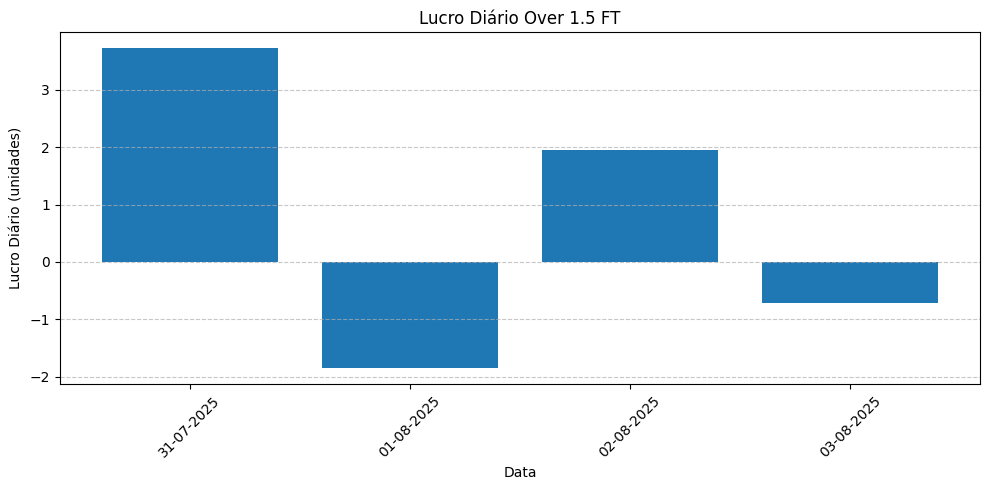

In [7]:
import matplotlib.pyplot as plt

# Extrai os pares (data, lucro)
dados = [(item["Data"], item["Lucro Diário (unidades)"]) for item in estatisticas_geral]

# Ordena os dados pela data convertida
dados_ordenados = sorted(dados, key=lambda x: datetime.strptime(x[0], "%d-%m-%Y"))

# Separa as listas ordenadas
datas_ordenadas = [data for data, _ in dados_ordenados]
lucros_ordenados = [lucro for _, lucro in dados_ordenados]

# Cria o gráfico
plt.figure(figsize=(10, 5))
plt.bar(datas_ordenadas, lucros_ordenados)
plt.xlabel("Data")
plt.ylabel("Lucro Diário (unidades)")
plt.title("Lucro Diário Over 1.5 FT")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [8]:
acertos = (df['Gols_Home'] + df['Gols_Away'] >= 2).sum()
odd_media_over = df['Odd_Over15'].mean()


estatisticas = {
    "Total de Jogos": len(df),
    "Total de Acertos": acertos,
    "Total de Derrotas": len(df) - acertos,
    "Taxa Mínima de Acerto (%)": round((1 / odd_media_over) * 100, 2),
    "Taxa de Acertos  (%)": round((acertos / len(df)) * 100, 2),
    "Odd Média": round(odd_media_over, 2),
    "Lucro Total (unidades)": round(df['Lucro_Over15'].sum(), 2),
    "ROI (%)": round((df['Lucro_Over15'].sum() / len(df)) * 100, 2),   
}
print("📊 RESUMO FINAL 📊")
for chave, valor in estatisticas.items():
    print(f"{chave}: {valor}")

📊 RESUMO FINAL 📊
Total de Jogos: 102
Total de Acertos: 87
Total de Derrotas: 15
Taxa Mínima de Acerto (%): 82.28
Taxa de Acertos  (%): 85.29
Odd Média: 1.22
Lucro Total (unidades): 3.1
ROI (%): 3.04
